In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split


In [25]:
data = pd.read_csv('PlayTennis.csv')
data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [26]:
from sklearn.preprocessing import OrdinalEncoder
outlook_encoder = OrdinalEncoder()
data['Outlook'] = outlook_encoder.fit_transform(data[['Outlook']])
temperature_encoder = OrdinalEncoder()
data['Temperature'] = temperature_encoder.fit_transform(data[['Temperature']])
humidity_encoder = OrdinalEncoder()
data['Humidity'] = humidity_encoder.fit_transform(data[['Humidity']])
windy_encoder = OrdinalEncoder()
data['Wind'] = windy_encoder.fit_transform(data[['Wind']])
PlayTennis_encoder = OrdinalEncoder()
data['Play Tennis'] = PlayTennis_encoder.fit_transform(data[['Play Tennis']])

In [27]:
data

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,1.0,0.0,1.0,0.0
1,2.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,1.0
3,1.0,2.0,0.0,1.0,1.0
4,1.0,0.0,1.0,1.0,1.0
5,1.0,0.0,1.0,0.0,0.0
6,0.0,0.0,1.0,0.0,1.0
7,2.0,2.0,0.0,1.0,0.0
8,2.0,0.0,1.0,1.0,1.0
9,1.0,2.0,1.0,1.0,1.0


In [28]:
x = data.drop(['Play Tennis'],axis=1)
y = data['Play Tennis']

In [29]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [30]:
clf = DecisionTreeClassifier(criterion='gini')
clf.fit(x_train,y_train)
y_pred = clf.predict(x_test)

In [31]:
clf1 = DecisionTreeClassifier(criterion='entropy')
clf1.fit(x_train,y_train)
y_pred_1 = clf1.predict(x_test)

In [32]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("Accuracy score for Gini :",accuracy_score(y_test,y_pred))
print("Classification report for Gini :\n",classification_report(y_test,y_pred))
print("Confusion matrix for Gini :\n",confusion_matrix(y_test,y_pred))

Accuracy score for Gini : 1.0
Classification report for Gini :
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion matrix for Gini :
 [[1 0]
 [0 2]]


In [33]:
print("Accuracy score for Entropy :",accuracy_score(y_test,y_pred_1))
print("Classification report for Entropy :\n",classification_report(y_test,y_pred_1))
print("Confusion matrix for Entropy :\n",confusion_matrix(y_test,y_pred_1))

Accuracy score for Entropy : 1.0
Classification report for Entropy :
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion matrix for Entropy :
 [[1 0]
 [0 2]]


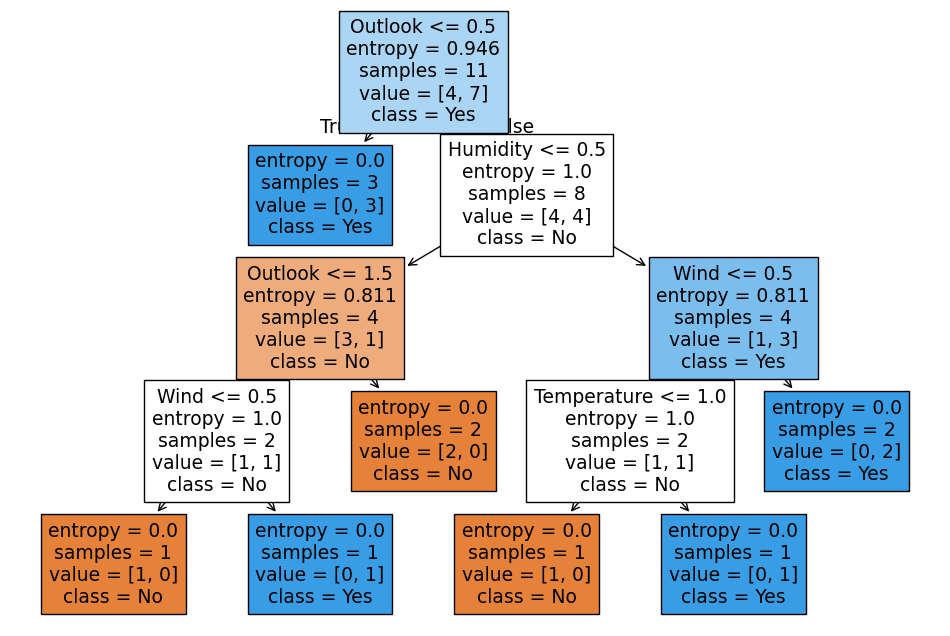

In [36]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(clf1,filled=True,feature_names=x.columns,class_names=PlayTennis_encoder.categories_[0])
plt.show()

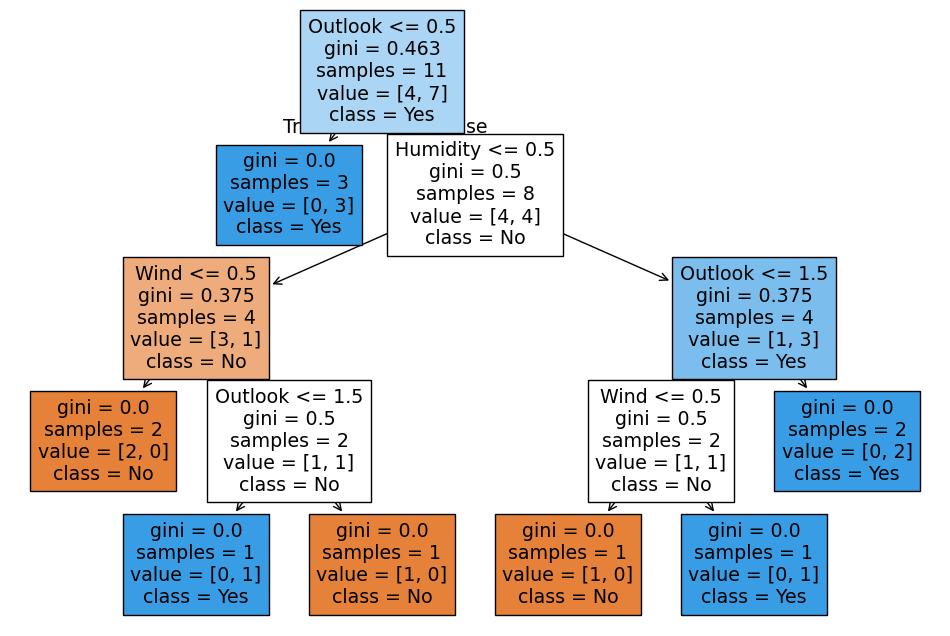

In [37]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(clf,filled=True,feature_names=x.columns,class_names=PlayTennis_encoder.categories_[0])
plt.show()